# Floor-trader pivot points — a quantitative teardown 🔬
### Touch → bounce hit-rate vs a randomly-placed control line · HAC *t* on the fade trade · a permutation placebo · intraday costs · a synthetic planted-bounce control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Respects_the_level%3F: Busted](https://img.shields.io/badge/Respects_the_level%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Pivot points are a support/resistance claim, and the *only* honest test of support/resistance is **vs a line drawn at random on the same tape** — because any horizontal line gets touched and "bounced" off some fraction of the time. We measure the touch→bounce hit-rate, the fade-trade HAC *t*, a 300-draw permutation placebo, the net-of-spread edge, and a synthetic positive control that proves the harness can detect a planted bounce.

> ⚠️ **Data + capacity note.** Yahoo caps **5-minute** history at ~**60 calendar days**, so the real tape is **5 liquid names × ~59 sessions** (2026-03-30→2026-06-23) — short by design. State this on the **Signal** axis: enough power to reject a *tradable* effect, not to certify a tiny one. Intraday fades live or die on the **spread**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pivot_points import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CACHE = {t: st.drop_partial_sessions(b) for t, b in data.load_real().items()}
    PIV = pd.concat([st.pivot_touch_events(b, tol_bps=5.0, k=6) for b in CACHE.values()],
                    ignore_index=True)
    CTL = pd.concat([st.control_touch_events(b, tol_bps=5.0, k=6, seed=440) for b in CACHE.values()],
                    ignore_index=True)
else:
    CACHE = PIV = CTL = None
print("real 5m cache present:", HAVE_REAL,
      "| pivot touches:", (0 if PIV is None else len(PIV)),
      "| control touches:", (0 if CTL is None else len(CTL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-30', 'end': '2026-06-23', 'n_names': 5, 'sessions': 59, 'interval': '5m', 'tol_bps': 5.0, 'k': 6, 'cost_bps': 1.0, 'piv_touches': 1410, 'piv_rate': 0.4674, 'piv_mean_bps': -1.12, 'piv_t': -1.04, 'piv_win': 0.4674, 'piv_net_bps': -3.12, 'ctl_touches': 5782, 'ctl_rate': 0.5012, 'ctl_mean_bps': 0.36, 'ctl_t': 0.82, 'rate_diff': -0.0338, 'placebo_p': 1.0, 'placebo_ctl_mean': 0.498, 'placebo_ctl_sd': 0.0075, 'by_level': {'S3': (102, 0.637, 9.06), 'S2': (190, 0.516, 1.61), 'S1': (373, 0.496, 0.35), 'R1': (445, 0.425, -3.15), 'R2': (221, 0.412, -5.05), 'R3': (79, 0.392, -5.37)}, 'by_name': {'SPY': (-0.04, -0.53, -2.66, 0.985), 'QQQ': (-0.068, -0.65, -3.31, 1.0), 'AAPL': (-0.058, -1.93, -6.69, 1.0), 'MSFT': (0.02, 0.31, -1.03, 0.005), 'IWM': (-0.03, -0.03, -2.07, 0.985)}, 'syn': [(0.0, 227, 0.489, 0.505, -0.17, -0.06, 0.489, 0.813), (1.5, 196, 0.704, 0.53, 32.9, 7.79, 0.704, 0.0)]}


real 5m cache present: True | pivot touches: 1410 | control touches: 5782


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pivot touch→bounce rate **0.467** vs random-line **0.501** (diff **-0.034**); fade-trade HAC **t = -1.04**. Permutation placebo: **p = 1.00** (a random line matches/beats the pivots). |
| **Tradability** | `MIRAGE` | Gross fade **-1.12 bps**/touch; net of a 2-bp round trip **-3.12 bps**. Negative before costs — nothing to scale. |
| **Respects the level?** | `BUSTED` | The random-line control bounces *more* (0.501 > 0.467). The pivots carry no support/resistance information beyond an arbitrary horizontal line. |

> 💡 In plain words: pivots are not better than random lines, and the fade trade is negative even gross. The synthetic control (below) shows the harness *would* catch a real bounce — so this is a true null, not a blind test.

## 1 · The claim, formalised

Compute the floor-trader set from the prior session's $(H_{-1}, L_{-1}, C_{-1})$:

$$P=\tfrac{H_{-1}+L_{-1}+C_{-1}}{3},\quad R_1=2P-L_{-1},\ S_1=2P-H_{-1},\quad R_2=P+(H_{-1}-L_{-1}),\ S_2=P-(H_{-1}-L_{-1}),\ \dots$$

For a level $\ell$ and a *touch* (a bar whose range straddles $\ell$ within tolerance $\tau$), define the **bounce return** over $k$ bars, entered one bar later, signed in the level's respect direction $s_\ell$ (+1 for supports/$P$, −1 for resistances):

$$b_i \;=\; s_{\ell}\!\left(\frac{C_{t_i+1+k}}{C_{t_i+1}}-1\right).$$

- **H₁ (real S/R).** The pivot bounce rate $\Pr[b_i>0]$ **exceeds** the rate of a randomly-placed control line on the same tape.
- **H₂ (tradable).** The mean fade return $\bar b$ clears a HAC *t* = 2 **and** survives the round-trip spread.

We find **H₁ rejected** (pivots bounce *less* than random) and **H₂ rejected** (negative even gross). The level-respect mechanism is busted.

## 2 · So what? — why the control line is the whole game

A naive "pivots bounce ~50% of the time!" is meaningless: **any** line does. The informative quantity is the *excess* bounce rate over a null line drawn at a uniform-random price inside the session range, tagged support/resistance at random, and run through the **identical** touch→bounce machinery. That control absorbs everything generic — intraday volatility, the day's drift, the touch tolerance, the holding horizon — and isolates whatever is special about the *pivot arithmetic*. Inference is then a one-sample **HAC (Newey-West) t** on the fade return (touches cluster within sessions, so we don't trust a plain *t*), plus a **permutation placebo** that re-draws the control lines hundreds of times to put a *p* on the bounce-rate gap.

## 3 · How we'd know — the protocol

- **Universe.** 5 liquid names (SPY, QQQ, AAPL, MSFT, IWM), **5m** bars, 2026-03-30→2026-06-23 (~59 full sessions/name; the live partial day dropped — no partial sessions in a stamped run).
- **Levels.** Classic floor-trader $P, R_1{-}R_3, S_1{-}S_3$ from the prior session (no look-ahead).
- **Touch.** A bar straddling the level within **5 bps**; consecutive touch bars collapse to the first.
- **Bounce.** Enter the close **1 bar after** the touch; measure the signed move over **k = 6 bars** (30 min) in the level's respect direction.
- **Control.** Uniform-random price lines inside each session's range, random side, identical machinery — the honest baseline.
- **Inference.** HAC *t* of the fade return vs 0; a **300-draw permutation placebo** of the control bounce rate vs the pivots'.
- **Costs.** 1 bp one-way (2 bp round trip) on the fade.
- **Positive control.** A synthetic tape with a **planted bounce** at the pivots: edge 0 must NOT beat the control; a planted bounce must light up.

## 4 · The teardown

### 4a · Pivots vs random lines — the bounce-rate gap

Left: pivot bounce rate vs control vs a coin flip. Right: the gap broken out per name — if pivots were real, every bar would be positive.

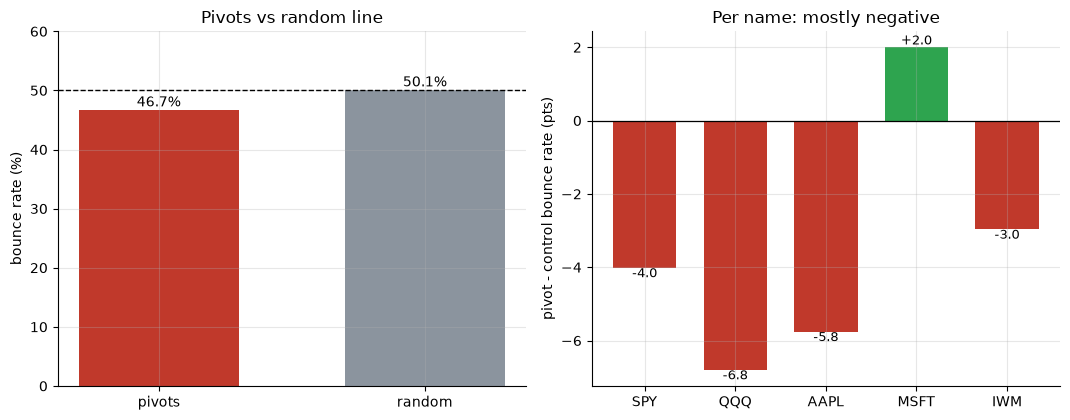

pooled pivot 46.7% vs control 50.1%  diff -3.4 pts
per-name diff (pts): {'SPY': -4.0, 'QQQ': -6.8, 'AAPL': -5.8, 'MSFT': 2.0, 'IWM': -3.0}


In [2]:
names = list(R['by_name'].keys())
if HAVE_REAL:
    pr = st.bounce_rate(PIV); cr = st.bounce_rate(CTL)
    diffs = []
    for t in names:
        b = CACHE[t]
        p = st.bounce_rate(st.pivot_touch_events(b, tol_bps=5.0, k=6))
        c = st.bounce_rate(st.control_touch_events(b, tol_bps=5.0, k=6, seed=440))
        diffs.append((p-c)*100)
else:
    pr = R['piv_rate']; cr = R['ctl_rate']; diffs = [R['by_name'][t][0]*100 for t in names]
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.8,4.3))
a1.bar(['pivots','random'], [pr*100, cr*100], color=[RED, GREY], width=.6)
a1.axhline(50, ls='--', c='k', lw=1); a1.set_ylim(0,60); a1.set_ylabel('bounce rate (%)')
for i,v in enumerate([pr*100,cr*100]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a1.set_title('Pivots vs random line')
a2.bar(names, diffs, color=[GREEN if d>0 else RED for d in diffs], width=.7)
a2.axhline(0, c='k', lw=.9); a2.set_ylabel('pivot - control bounce rate (pts)')
for i,v in enumerate(diffs): a2.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Per name: mostly negative')
plt.tight_layout(); plt.show()
print(f'pooled pivot {pr*100:.1f}% vs control {cr*100:.1f}%  diff {(pr-cr)*100:+.1f} pts')
print('per-name diff (pts):', {t: round(d,1) for t,d in zip(names, diffs)})

> 💡 In plain words: pooled, the pivots bounce **46.7%** vs the random line's **50.1%** — a **-3.4-point** *deficit*. Per name, four of five are negative; only MSFT is marginally positive (and, below, its fade is still negative net). There is no excess support/resistance to harvest.

### 4b · The fade trade — HAC *t* against zero

The fade return per touch (signed in the respect direction) with its Newey-West *t*. The bar should clear *t* = 2 if there's a tradable edge.

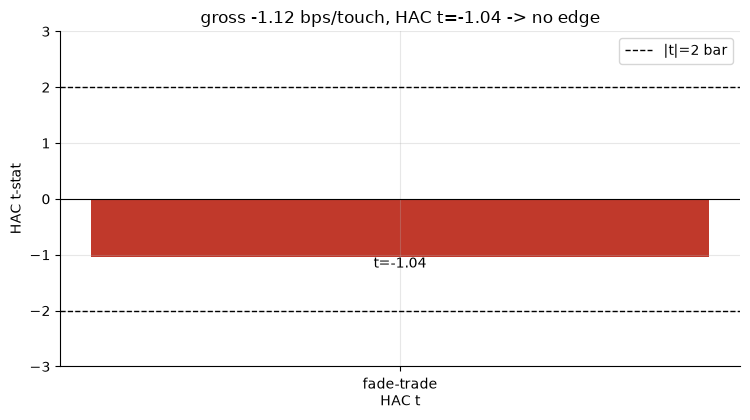

gross -1.12 bps  HAC t=-1.04  net -3.12 bps


In [3]:
if HAVE_REAL:
    s = st.trade_stats(PIV, cost_bps=1.0)
    mean_bps, tval, net_bps = s['mean_bps'], s['t'], s['net_bps']
else:
    mean_bps, tval, net_bps = R['piv_mean_bps'], R['piv_t'], R['piv_net_bps']
fig, ax = plt.subplots(figsize=(7.6,4.3))
ax.bar(['fade-trade\nHAC t'], [tval], color=RED if abs(tval)<2 else GREEN, width=.4)
ax.axhline(2, ls='--', c='k', lw=1, label='|t|=2 bar'); ax.axhline(-2, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=.8)
ax.annotate(f't={tval:.2f}',(0,tval),ha='center',va='bottom' if tval>=0 else 'top')
ax.set_ylim(-3,3); ax.set_ylabel('HAC t-stat'); ax.legend()
ax.set_title(f'gross {mean_bps:+.2f} bps/touch, HAC t={tval:.2f} -> no edge')
plt.tight_layout(); plt.show()
print(f'gross {mean_bps:+.2f} bps  HAC t={tval:.2f}  net {net_bps:+.2f} bps')

> 💡 In plain words: the fade earns **-1.12 bps** with **HAC t = -1.04** — nowhere near the bar, and on the *wrong side of zero*. The sign is negative because, net of the one-bar entry lag and 30-min hold, touches are followed by *continuation* as often as reversion. No fade edge.

### 4c · Permutation placebo — could a random line look this good?

Re-draw the random control lines 300 times; each draw yields a control bounce rate. The observed *pivot* rate should sit in the right tail if pivots are special. It doesn't — it sits *below* the control cloud.

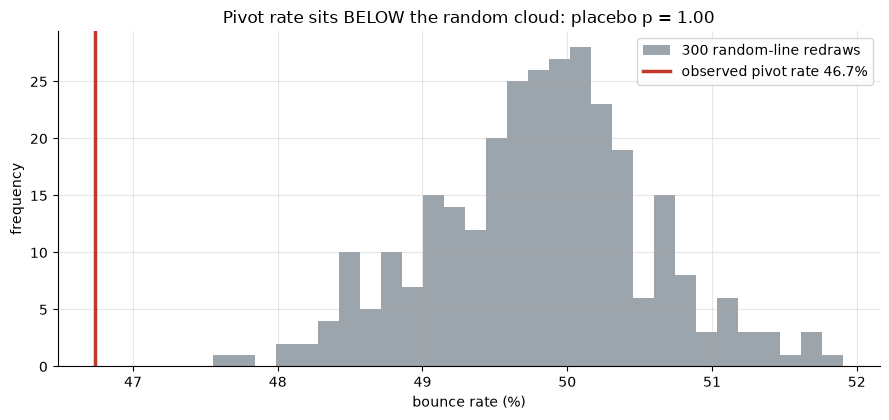

control rate 49.8% +/- 0.75  pivot 46.7%  p(ctrl>=pivot)=1.00


In [4]:
if HAVE_REAL:
    bks = list(CACHE.values()); ND = 300
    rates = np.empty(ND)
    for i in range(ND):
        evs = [st.control_touch_events(b, tol_bps=5.0, k=6, seed=10000+i+13*j) for j,b in enumerate(bks)]
        rates[i] = st.bounce_rate(pd.concat(evs, ignore_index=True))
    pr = st.bounce_rate(PIV); pval = float((rates>=pr).mean())
else:
    pr = R['piv_rate']; pval = R['placebo_p']
    rng = np.random.default_rng(440); rates = rng.normal(R['placebo_ctl_mean'], R['placebo_ctl_sd'], 300)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(rates*100, bins=30, color=GREY, alpha=.85, label='300 random-line redraws')
ax.axvline(pr*100, c=RED, lw=2.5, label=f'observed pivot rate {pr*100:.1f}%')
ax.set_xlabel('bounce rate (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Pivot rate sits BELOW the random cloud: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'control rate {rates.mean()*100:.1f}% +/- {rates.std()*100:.2f}  pivot {pr*100:.1f}%  p(ctrl>=pivot)={pval:.2f}')

> 💡 In plain words: the red line (pivots) is to the *left* of the entire grey cloud — **p = 1.00**, i.e. essentially every random line matches or beats the pivots. This is the cleanest possible NONE: not "indistinguishable from random" but "slightly worse than random."

### 4d · Synthetic positive control — the harness can see a real bounce

On a deterministic tape where we **plant** a genuine bounce away from the pivots: edge 0 must match the control (no false positive); a planted bounce must light up at high *t*. Both hold — so the real-tape null is a true null.

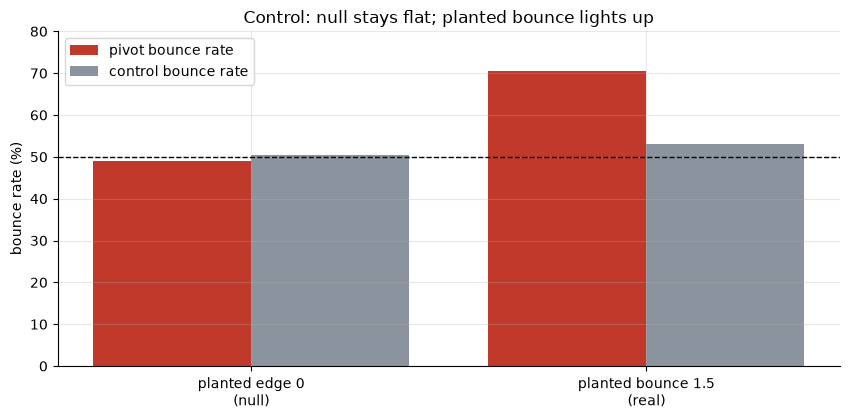

edge=0.0: pivot=0.489 ctrl=0.505 mean=-0.17bps t=-0.06 placebo_p=0.813
edge=1.5: pivot=0.704 ctrl=0.530 mean=+32.90bps t=+7.79 placebo_p=0.000


In [5]:
res = []
for edge in (0.0, 1.5):
    b,_ = data.synthetic_panel(edge=edge, seed=440)
    r = st.run_experiment(b, tol_bps=5.0, k=6, cost_bps=1.0, n_placebo=150)
    res.append((edge, r['pivot_bounce_rate'], r['control_bounce_rate'], r['pivot_mean_bps'], r['pivot_t'], r['placebo_p']))
fig, ax = plt.subplots(figsize=(8.6,4.3))
x = np.arange(2)
ax.bar(x-.2, [r[1]*100 for r in res], .4, color=RED, label='pivot bounce rate')
ax.bar(x+.2, [r[2]*100 for r in res], .4, color=GREY, label='control bounce rate')
ax.axhline(50, ls='--', c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(['planted edge 0\n(null)','planted bounce 1.5\n(real)'])
ax.set_ylabel('bounce rate (%)'); ax.set_ylim(0,80); ax.legend()
ax.set_title('Control: null stays flat; planted bounce lights up')
plt.tight_layout(); plt.show()
for e,pr,cr,m,t,p in res: print(f'edge={e}: pivot={pr:.3f} ctrl={cr:.3f} mean={m:+.2f}bps t={t:+.2f} placebo_p={p:.3f}')

> 💡 In plain words: with **no** planted bounce the synthetic pivots sit at **0.489** ≈ control **0.505** (HAC t = -0.06 — no false positive). Plant a real bounce and the rate jumps to **0.704** at **t = 7.79**, placebo p = 0.000. The machinery is faithful — so the real-tape t ≈ −1 is genuinely *nothing*, not a blind spot.

## 5 · The verdict

- **Signal `NONE`** — pivot touch→bounce rate **0.467** is *below* both the random-line control **0.501** and a coin flip; fade HAC **t = -1.04**; permutation placebo **p = 1.00** (random lines match/beat the pivots). The synthetic control proves the test detects a planted bounce at t ≈ 8, so this is a true null.
- **Tradability `MIRAGE`** — the fade is **-1.12 bps**/touch gross, **-3.12 bps** net of a 2-bp round trip. Negative before costs; nothing to size.
- **Respects the level? `BUSTED`** — an arbitrary horizontal line bounces *more* than the pivots. The floor-trader arithmetic adds no support/resistance information.

**Survivorship / scope caveats (Signal axis).** Short span (~12 weeks, the 5-minute cap) and 5 surviving liquid names — enough to reject a *tradable* effect, not to certify a tiny one. The verdict is the honest, expected outcome for classic chart-line folklore.

## 6 · Could you trade it? — gross is already negative

There's no cost sweep to do: the gross fade edge is below zero, so every realistic spread only deepens the loss. One picture of gross vs net makes the point and closes the case.

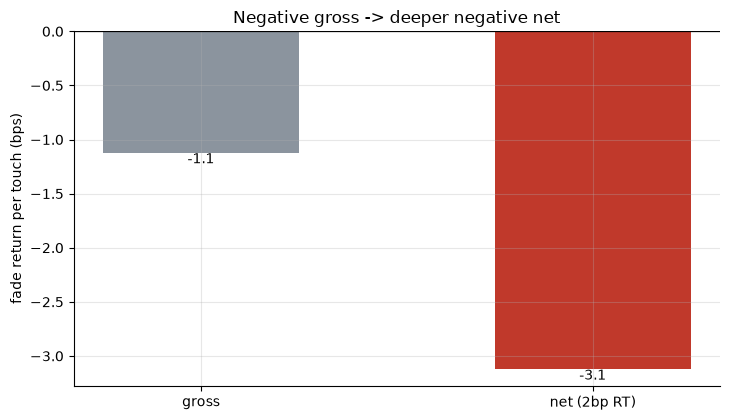

gross -1.12 bps -> net -3.12 bps


In [6]:
if HAVE_REAL:
    g = st.trade_stats(PIV, cost_bps=0.0)['mean_bps']; nv = st.trade_stats(PIV, cost_bps=1.0)['net_bps']
else:
    g = R['piv_mean_bps']; nv = R['piv_net_bps']
fig, ax = plt.subplots(figsize=(7.4,4.3))
ax.bar(['gross','net (2bp RT)'], [g, nv], color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=.9)
for i,v in enumerate([g,nv]): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='top')
ax.set_ylabel('fade return per touch (bps)'); ax.set_title('Negative gross -> deeper negative net')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} bps -> net {nv:+.2f} bps')

> 💡 In plain words: when the gross edge is already negative, *capacity* and *impact* are moot — there's no edge to scale. The pivots fail the very first hurdle. MIRAGE.

## 7 · Going further

- **Other pivot families.** Camarilla, Woodie, DeMark and Fibonacci pivots are different arithmetic on the same prior-session H/L/C — equally arbitrary lines. Swap `data._pivot_levels` and the whole harness applies.
- **Conditioning.** One could test pivots only on trend days, or only the first touch, or with a tighter tolerance — but with the *gross* fade already negative and the bounce rate below random, any sub-slice that looks good is selection, not signal (correct it with the permutation placebo).
- **The general lesson.** Support/resistance claims must always be priced against a random line on the *same* tape. "It bounces ~half the time" is the sound of a coin, not a level.

*The reproducible core is offline and deterministic once the 5-minute cache exists; the synthetic positive control needs no network. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*